# MOVIELENS大作业

In [1]:
%pip install seaborn plotly lightgbm
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

warnings.filterwarnings('ignore')

#读取评分数据
ratings = pd.read_csv('./ratings2.csv', header=0, names=['user_id', 'movie_id', 'rating', 'timestamp'], 
    usecols=[0, 1, 2, 3], dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32', 'timestamp': 'int64'}, encoding='latin-1'
)

#读取用户信息
users = pd.read_csv('./users.csv', encoding='latin-1', usecols=['user_id', 'gender', 'zipcode', 'age_desc', 'occ_desc'])

#读取电影基本信息
movies = pd.read_csv('./movies.csv',  encoding='latin-1', usecols=['movie_id', 'title', 'genres'])

#读取电影详细信息并重命名列
movies_info = pd.read_csv('./info.csv',  encoding='latin-1', usecols=['id', 'name', 'genre','intro','directors','starts', 'release_time'])
movies_info.rename(columns ={ 'id':'movie_id'}, inplace = True)

Note: you may need to restart the kernel to use updated packages.


## 一、传统偏好发现

### checkpoint里已经给出的男女偏好分析部分略，下面为年龄偏好分析部分的实现

### 年龄偏好分析

In [2]:
#筛选观影人次>300的电影
popular = ratings['movie_id'].value_counts()
popular = popular[popular > 300]
popular = popular.rename('count')
popular = popular.rename_axis('movie_id')

#合并用户、评分、电影数据
merged_data = pd.merge(ratings[['user_id', 'movie_id', 'rating']], users[['user_id', 'age_desc']], on='user_id').merge(
    movies[['movie_id', 'title', 'genres']], on='movie_id')

#仅保留流行电影数据
filtered_data = merged_data[merged_data['movie_id'].isin(popular.index)]

In [3]:

def calculate_age_preference(age_group_name, global_mean_ref):
    #过滤当前年龄段数据
    group_data = filtered_data[filtered_data['age_desc'] == age_group_name]
    
    #计算组内平均分和观影次数
    group_mean = group_data.groupby('movie_id')['rating'].mean().rename('group_mean')
    n = group_data.groupby('movie_id').size().rename('n')
    
    #指标1：评分差异加权
    movie_global_mean = filtered_data.groupby('movie_id')['rating'].mean()
    delta_rating = (group_mean - movie_global_mean).rename('delta_rating')
    score1 = (delta_rating * np.log(n + 1)).rename('score1')  #+1防止log(0)
    
    #指标2：贝叶斯加权评分
    N_avg = n.mean()
    W = (0.5 * n / N_avg).clip(upper=1.0)
    bayesian_score = (W * group_mean + (1 - W) * global_mean_ref).rename('score2')
    
    #合并结果
    score_df = pd.concat([delta_rating, n, score1, bayesian_score], axis=1)
    return score_df.reset_index()

下面这部分的输出略去

In [4]:
# #获取所有age_desc分类
# age_groups = filtered_data['age_desc'].unique().tolist()

# #全局平均分用于贝叶斯计算
# global_mean = filtered_data['rating'].mean()

# for age_group in age_groups:
#     #计算当前年龄组的偏好得分
#     score_df = calculate_age_preference(age_group, global_mean)
    
#     #合并电影信息
#     result_df = score_df.merge(
#         movies[['movie_id', 'title', 'genres']],
#         on='movie_id'
#     ).sort_values('score1', ascending=False)
    
#     #展示Top10（评分差异指标）
#     print(f"\n{age_group} 组偏好Top10（评分差异）")
#     display(
#         result_df.head(10)[['title', 'genres', 'score1', 'delta_rating', 'n']]
#         .rename(columns={'score1': '偏好得分', 'delta_rating': '评分差异', 'n': '观影次数'})
#         .reset_index(drop=True)
#         .set_axis(pd.RangeIndex(1, 11), axis='index')
#         .rename_axis('排名')
#     )
    
#     #展示Top10（贝叶斯指标）
#     print(f"\n{age_group} 组偏好Top10（贝叶斯加权）")
#     display(
#         result_df.sort_values('score2', ascending=False)
#         .head(10)[['title', 'genres', 'score2', 'n']]
#         .rename(columns={'score2': '贝叶斯评分', 'n': '观影次数'})
#         .reset_index(drop=True)
#         .set_axis(pd.RangeIndex(1, 11), axis='index')
#         .rename_axis('排名')
#     )

### 基于电影风格的年龄偏好可视化实现

数据预处理与类型展开

In [5]:
#展开电影类型为二进制列
movies_genres = pd.concat([movies['movie_id'], movies['genres'].str.get_dummies(sep='|').add_prefix('genre_')], axis=1)

#合并用户、评分、电影数据
full_data = pd.merge(filtered_data, movies_genres, on='movie_id',how='inner')

计算核心指标

In [6]:
#获取所有电影类型列表
genre_columns = [col for col in full_data.columns if col.startswith('genre_')]

#初始化结果容器
age_groups = full_data['age_desc'].unique()
genre_stats = []

#按年龄组和类型逐个计算指标
for age_group in age_groups:
    group_data = full_data[full_data['age_desc'] == age_group]
    
    for genre in genre_columns:
        #筛选当前类型的评分数据
        genre_ratings = group_data[group_data[genre] == 1]['rating']
        record = {
            'age_group': age_group,
            'genre': genre.replace('genre_', ''),
            'mean_rating': genre_ratings.mean(),
            'watch_count': len(genre_ratings)
        }
        genre_stats.append(record)

#转换为DataFrame
genre_stats_df = pd.DataFrame(genre_stats)

#计算占比
total_watch = genre_stats_df.groupby('age_group')['watch_count'].transform('sum')
genre_stats_df['watch_percent'] = genre_stats_df['watch_count'] / total_watch * 100

可视化1：各年龄组类型平均评分对比

数据前5行：
   age_group       genre  mean_rating  watch_count  watch_percent
0  Under 18      Action     3.596417         5917      12.639921
1  Under 18   Adventure     3.570088         3303       7.055883
2  Under 18   Animation     3.632527         1943       4.150645
3  Under 18  Children's     3.452830         2650       5.660942
4  Under 18      Comedy     3.667029         8271      17.668547

数据类型：
 age_group         object
genre             object
mean_rating      float32
watch_count        int64
watch_percent    float64
dtype: object


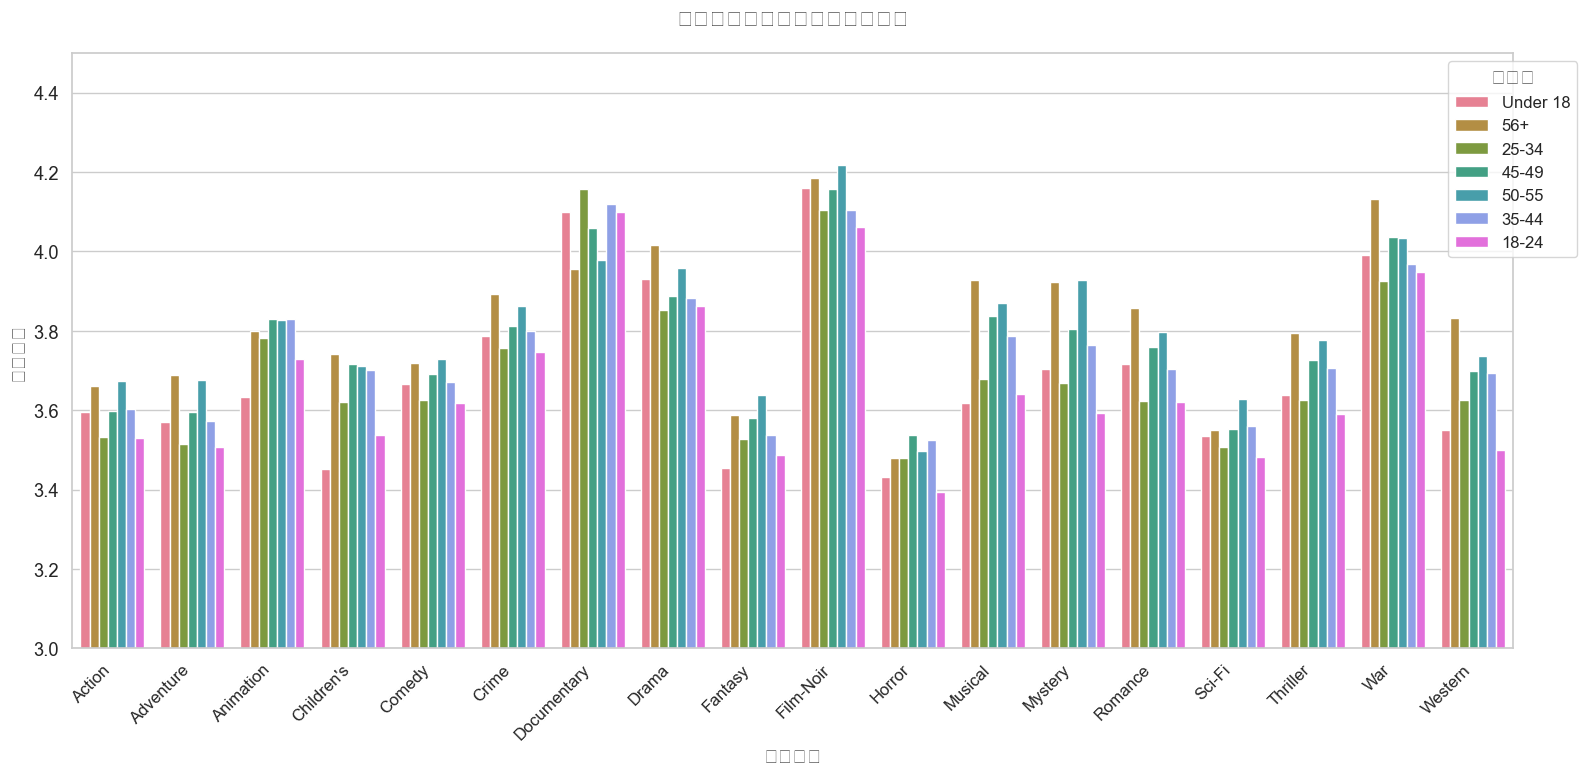

In [7]:
#设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
#设置主题
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.2)

#检查数据格式
print("数据前5行：\n", genre_stats_df.head())
print("\n数据类型：\n", genre_stats_df.dtypes)

plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=genre_stats_df,
    x='genre',
    y='mean_rating',
    hue='age_group',
    errorbar=None,
    order=sorted(genre_stats_df['genre'].unique()),
    dodge=True
)
plt.ylim(3.0, 4.5)
plt.title('各年龄组电影类型平均评分对比', fontsize=16, pad=20)
plt.xlabel('电影类型', fontsize=14)
plt.ylabel('平均评分', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(np.arange(3.0, 4.6, 0.2))
plt.legend(title='年龄组', bbox_to_anchor=(1.05, 1), fontsize=12)
plt.tight_layout()
plt.show()

可视化2：各年龄组观影数量堆叠图

<Figure size 1400x800 with 0 Axes>

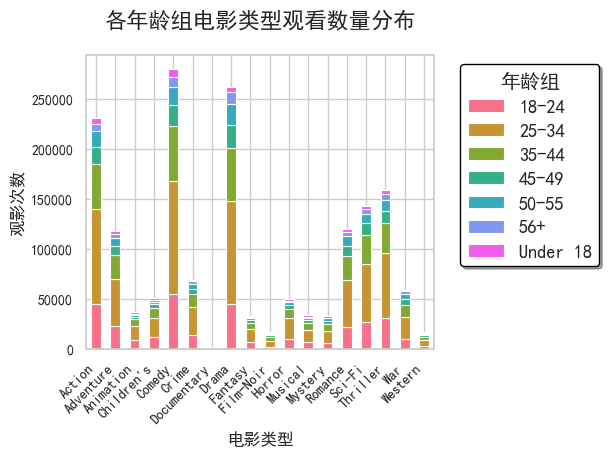

In [8]:
#设置全局样式
sns.set_theme(
    style="whitegrid",
    palette="husl",
    font_scale=1.2
)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#数据透视处理
pivot_count = genre_stats_df.pivot_table(
    index='genre',
    columns='age_group',
    values='watch_count',
    aggfunc='sum'
).fillna(0)

#绘制堆叠柱状图
plt.figure(figsize=(14, 8))
ax = pivot_count.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette("husl", n_colors=pivot_count.shape[1]),  #使用seaborn调色板
    edgecolor='w',  #添加白色边框
    linewidth=0.8
)

#图表装饰
plt.title('各年龄组电影类型观看数量分布', fontsize=16, pad=20)
plt.xlabel('电影类型', fontsize=12)
plt.ylabel('观影次数', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

#优化图例
legend = ax.legend(
    title='年龄组',
    bbox_to_anchor=(1.05, 1),
    frameon=True,
    shadow=True,
    edgecolor='black'
)
legend.get_frame().set_facecolor('white')

plt.tight_layout()
plt.show()

分析结果

In [9]:
analysis_report = []

#1.找出每个年龄组最偏好的类型
age_groups = genre_stats_df['age_group'].unique()
for age_group in sorted(age_groups):
    group_data = genre_stats_df[genre_stats_df['age_group'] == age_group]
    #数据校验
    #if group_data.empty:
    #    analysis_report.append(f"{age_group} 组无有效数据")
    #    continue
    try:
        top_genre = group_data.loc[group_data['watch_percent'].idxmax()]
        analysis_report.append(
            f"{age_group} 组最偏好类型：{top_genre['genre']} "
            f"(占比 {top_genre['watch_percent']:.1f}%)"
        )
    except ValueError:
        analysis_report.append(f"{age_group} 组数据异常")

#2.找出评分差异最大的类型
try:
    rating_std = genre_stats_df.groupby('genre')['mean_rating'].std()
    if not rating_std.empty:
        max_diff = rating_std.idxmax()
        analysis_report.append(f"\n评分差异最大类型：{max_diff} (标准差：{rating_std[max_diff]:.2f})")
    else:
        analysis_report.append("\n评分数据不足")
except Exception as e:
    analysis_report.append(f"\n评分分析失败：{str(e)}")

print("结果分析\n")
print("\n".join(analysis_report))

结果分析

18-24 组最偏好类型：Comedy (占比 16.9%)
25-34 组最偏好类型：Comedy (占比 16.6%)
35-44 组最偏好类型：Comedy (占比 16.1%)
45-49 组最偏好类型：Drama (占比 16.7%)
50-55 组最偏好类型：Drama (占比 17.5%)
56+ 组最偏好类型：Drama (占比 19.4%)
Under 18 组最偏好类型：Comedy (占比 17.7%)

评分差异最大类型：Mystery (标准差：0.13)


## 二、用户对电影的打分预测

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import datetime
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
import re
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



### 示例：基于SVD对用户电影评分数据进行协同过滤预测

这里SVD分解时间较长，略去

### 请你不要局限于对评分矩阵做SVD分解，尝试加入用户类型及偏好进行优化。另：加入电影信息获得好的效果可以加5分。

In [11]:
#基于混合特征的评分预测系统实现
users = pd.read_csv( './users.csv', usecols=['user_id', 'gender', 'age_desc', 'occ_desc'],
        dtype={'user_id': 'int32', 'gender': 'category'}, encoding='latin-1')
movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
        dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv( './info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
        dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'},encoding='latin-1'
    ).rename(columns={'id': 'movie_id'})

#内存优化：通过指定dtype参数减少内存占用
#category类型适用于有限取值的字符串字段（如gender）
#特征融合：将导演、编剧、主演合并为creative_team字段
#|符分隔保留原始信息便于后续文本特征提取

def extract_year(time_str):
    try:
        return pd.to_datetime(time_str, errors='coerce').year.fillna(2000).astype(int)
    except:
        return 2000
def process_age(age_desc):
    age_map = {'Under 18': 18, '18-24': 21, '25-34': 30, '35-44': 40, '45-49': 47, '50-55': 52, '56+': 60}
    return age_desc.map(age_map)

users['age'] = process_age(users['age_desc'])
movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['starts']

#合并评分数据和真实用户数据
data = pd.merge(ratings, users, on='user_id')
#继续合并电影数据
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

data['release_year'] = data['release_year'].fillna(2000)
text_columns = ['creative_team', 'intro', 'directors', 'writers', 'starts']
data[text_columns] = data[text_columns].fillna('Unknown')
data['creative_team'] = data['creative_team'].replace('', 'Unknown')

In [12]:
#特征工程处理流程

#用户特征处理逻辑：

#原始特征 → OneHot编码 → PCA降维 → 低维稠密向量
#PCA n_components=0.95 自适应降维至保留95%原始信息
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

#电影特征处理逻辑：

#genres处理：
#直接进行OneHot编码，生成类型特征矩阵

#creative_team处理：
#TF-IDF参数：tokenizer=lambda x: x.split('|')：按管道符分割人名；max_features=500：保留最高频500个人物
#TruncatedSVD压缩至50维

#intro处理：
#ngram_range=(1,2)捕获单词和短语
#100维保留关键语义信息
movie_transformer = ColumnTransformer(
    [   ('genres', OneHotEncoder(), ['genres']),

        (   'creative_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(tokenizer=lambda x: x.split('|'),max_features=500,min_df=5)),
                    ('svd', TruncatedSVD(n_components=50, random_state=42))   ]
            ),
            'creative_team'   ),

        (   'intro_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ), 
            'intro'   ),
        
        ('year', 'passthrough', ['release_year'])   ]
)

#全局特征处理器

#输入数据 → 列分流处理（分为用户特征(OneHot+PCA)+电影特征(多模态处理)） → 特征拼接 → 最终特征矩阵
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender', 'age', 'occ_desc']),
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year'])
], remainder='drop')

In [13]:
#划分数据集
X = data[['gender', 'age', 'occ_desc', 'genres', 'creative_team', 'intro', 'release_year']]
y = data['rating']
#20%测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('preprocessor', preprocessor), #特征工程
    ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, #LightGBM回归
        subsample=0.8, random_state=42, verbose=-1))
])
#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

from sklearn.metrics import accuracy_score

#将预测值四舍五入到最近整数
y_pred_class = np.round(preds).clip(1, 5)  #限制在1-5分
y_test_class = np.round(y_test).clip(1, 5)

acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')
#MSE（0.9680）
#Accuracy（0.3757）
#四舍五入后计算分类准确率
#37.57%的准确率在5分类任务中属于合理水平

MSE: 0.9703
Accuracy: 0.3772


In [14]:

# 评分参考
def grade(score):
    if score >= 2:
        return 0
    elif score >= 1:
        return 30
    else:
        return 40
print("Score:",grade(mse))

Score: 40


## 三、电影海报聚类分析

In [15]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
from img2vec_pytorch import Img2Vec

#文件夹路径
folder_path = "./poster"

#初始化特征列表
features = []

img2vec_model = Img2Vec()
#遍历文件夹中的每个海报图像
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        #读取图像
        image_path = os.path.join(folder_path, filename)
        image = cv2.imread(image_path)

        #提取颜色直方图和灰度直方图特征
        image = Image.open(image_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')
        vector = img2vec_model.get_vec(image)

        feature_vector = vector

        #添加图像文件前缀（电影ID）和特征向量到特征列表中
        features.append([filename.split('.')[0], feature_vector])

#将特征列表转换为DataFrame
columns = ['movie_id', 'features']
df = pd.DataFrame(features, columns=columns)

print("带有电影ID和特征向量的DataFrame:")
print(df.head())

带有电影ID和特征向量的DataFrame:
  movie_id                                           features
0        1  [1.2273525, 1.1728468, 0.29160962, 3.7952738, ...
1       10  [0.6591355, 0.563311, 0.1754671, 0.47256583, 0...
2      100  [1.270225, 2.129366, 0.1338063, 0.0, 0.0327485...
3     1003  [1.4408051, 1.2796657, 0.79114556, 0.65906763,...
4     1004  [0.54259104, 0.7196604, 0.11201007, 0.7017186,...


### 无监督聚类结果的可视化

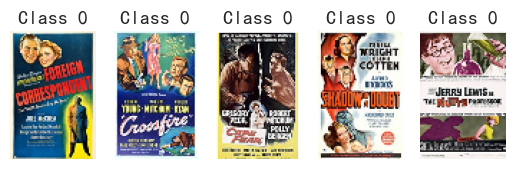

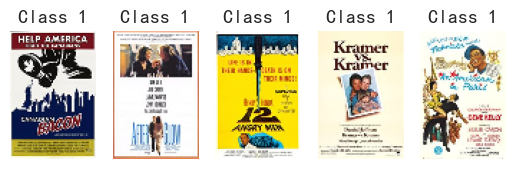

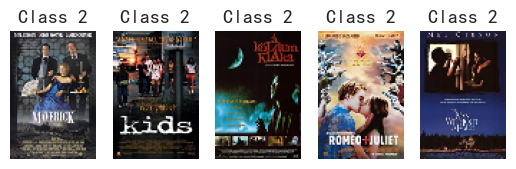

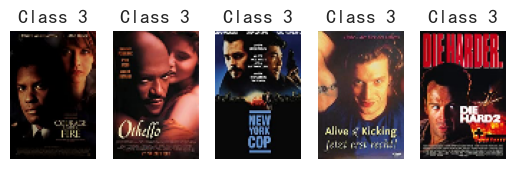

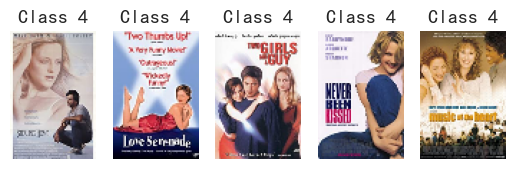

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#将特征向量转换为numpy数组
feature_matrix = np.vstack(df['features'].values)

#执行K-means聚类（假设分为5类）
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(feature_matrix)

#获取每个类别的代表性图像（每个类别取5个）
representative_images = []
for i in range(n_clusters):
    #获取当前类别的所有样本索引
    class_indices = np.where(cluster_labels == i)[0]
    
    #计算样本到聚类中心的距离
    distances = np.linalg.norm(feature_matrix[class_indices] - kmeans.cluster_centers_[i], axis=1)
    
    #选择距离最近的5个样本作为代表
    representative_indices = class_indices[np.argsort(distances)[:5]]
    representative_images.append(representative_indices)

#打印每个类别的代表性图像
for i, indices in enumerate(representative_images):
    #设置图像的大小
    for j, index in enumerate(indices):
        #读取代表性图像
        representative_image_path = os.path.join(folder_path, os.listdir(folder_path)[index])
        representative_image = cv2.imread(representative_image_path)
        representative_image = cv2.resize(representative_image, (60, 90))
        #绘制图像
        plt.subplot(1, 5, j+1)
        plt.imshow(cv2.cvtColor(representative_image, cv2.COLOR_BGR2RGB))
        plt.title("Class {}".format(i))
        plt.axis("off")

    plt.show()


### 有监督聚类

In [17]:
import pandas as pd

#读取CSV文件
movies_df = pd.read_csv("./movies.csv")

#提取genre信息
genres = movies_df['genres']
#初始化genre的字典
genre_dict = {}

#遍历每个电影的genre信息
for genre_string in genres:
    #将genre字符串按照"|"分割成列表
    genre_list = genre_string.split("|")
    #遍历列表中的每个genre
    for genre in genre_list:
        #将genre添加到字典中，如果已存在则不重复添加
        if genre not in genre_dict:
            genre_dict[genre] = len(genre_dict)

#输出genre字典
print("Genre Dictionary:")
print(genre_dict)

Genre Dictionary:
{'Animation': 0, "Children's": 1, 'Comedy': 2, 'Adventure': 3, 'Fantasy': 4, 'Romance': 5, 'Drama': 6, 'Action': 7, 'Crime': 8, 'Thriller': 9, 'Horror': 10, 'Sci-Fi': 11, 'Documentary': 12, 'War': 13, 'Musical': 14, 'Mystery': 15, 'Film-Noir': 16, 'Western': 17}


In [18]:

#将genre信息转换为向量形式
genre_vectors = []

#遍历每个电影的genre信息
for genre_string in genres:
    #将genre字符串按照"|"分割成列表
    genre_list = genre_string.split("|")
    #初始化genre向量
    genre_vector = [0] * len(genre_dict)
    #根据genre列表设置向量中对应的位置为1
    for genre in genre_list:
        genre_vector[genre_dict[genre]] = 1
    #将genre向量添加到列表中
    genre_vectors.append(genre_vector)

#将genre向量转换为列表
genre_lists = [list(genre_vector) for genre_vector in genre_vectors]

#将genre列表添加到movies_df中
movies_df['genre_vector'] = genre_lists

#输出带有genre向量的movies_df
print("Movies DataFrame with Genre Vector:")
print(movies_df.head())

Movies DataFrame with Genre Vector:
   Unnamed: 0  movie_id                               title  \
0           0         1                    Toy Story (1995)   
1           1         2                      Jumanji (1995)   
2           2         3             Grumpier Old Men (1995)   
3           3         4            Waiting to Exhale (1995)   
4           4         5  Father of the Bride Part II (1995)   

                         genres  \
0   Animation|Children's|Comedy   
1  Adventure|Children's|Fantasy   
2                Comedy|Romance   
3                  Comedy|Drama   
4                        Comedy   

                                        genre_vector  
0  [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  


In [19]:
#将电影ID列转换为整数类型
movies_df['movie_id'] = movies_df['movie_id'].astype(int)
df['movie_id'] = df['movie_id'].astype(int)

In [20]:
#使用merge方法按照movie_id合并两个DataFrame
merged_df = pd.merge(movies_df, df, on='movie_id', how='inner')

#输出合并后的DataFrame
print("Merged DataFrame:")
print(merged_df.head())

Merged DataFrame:
   Unnamed: 0  movie_id                               title  \
0           0         1                    Toy Story (1995)   
1           1         2                      Jumanji (1995)   
2           2         3             Grumpier Old Men (1995)   
3           3         4            Waiting to Exhale (1995)   
4           4         5  Father of the Bride Part II (1995)   

                         genres  \
0   Animation|Children's|Comedy   
1  Adventure|Children's|Fantasy   
2                Comedy|Romance   
3                  Comedy|Drama   
4                        Comedy   

                                        genre_vector  \
0  [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                            features  


In [21]:
print(merged_df.columns)

Index(['Unnamed: 0', 'movie_id', 'title', 'genres', 'genre_vector',
       'features'],
      dtype='object')


### 性别预测

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#读取数据
ratings = pd.read_csv('ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'])
movies = pd.read_csv('movies.csv')
users = pd.read_csv('users.csv')[['user_id', 'gender']]

#筛选热门电影（评分次数 > 300）
popular_movies = ratings['movie_id'].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings['movie_id'].isin(popular_movies)]

#合并评分与电影类型数据
ratings_movies = pd.merge(ratings_filtered, movies, on='movie_id')

#拆分电影类型为多行
ratings_movies['genres'] = ratings_movies['genres'].str.split('|')
ratings_exploded = ratings_movies.explode('genres')

#计算用户对每个类型的平均评分
user_genre_avg = ratings_exploded.groupby(['user_id', 'genres'])['rating'].mean().unstack(fill_value=0)

In [23]:
#合并用户性别
data = pd.merge(users, user_genre_avg, on='user_id')

#将性别转换为数值（F=0, M=1）
data['gender'] = data['gender'].map({'F': 0, 'M': 1})

#分割特征和标签
X = data.drop(['user_id', 'gender'], axis=1)
y = data['gender']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#模型训练
#构建包含过采样-标准化-特征选择-分类器的完整管道
#SMOTE解决类别不平衡问题（F/M样本比1:1.8）
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=10)),
    ('classifier', LogisticRegression(class_weight="balanced", max_iter=1000))
])

#训练模型
pipeline.fit(X_train, y_train)

#预测与评估
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]


print("分类报告")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

分类报告
              precision    recall  f1-score   support

           0       0.41      0.54      0.47       294
           1       0.79      0.70      0.74       745

    accuracy                           0.65      1039
   macro avg       0.60      0.62      0.61      1039
weighted avg       0.69      0.65      0.67      1039

ROC-AUC: 0.6554809843400449


In [24]:
X_all = data.drop(['user_id', 'gender'], axis=1)
all_gender_pred = pipeline.predict(X_all)

#转换为'F'/'M'并合并到用户数据
data['gender_pred'] = all_gender_pred
data['gender_pred'] = data['gender_pred'].map({0: 'F', 1: 'M'})

#合并到原始用户表
users = pd.merge(users[['user_id', 'gender']], data[['user_id', 'gender_pred']], on='user_id', how='left')
users['gender_pred'] = users['gender_pred'].fillna(users['gender'])

#保存到CSV
users.to_csv("users_with_predictions.csv", index=False)

### 年龄预测

In [25]:
%pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, classification_report
from sklearn.ensemble import GradientBoostingClassifier
import mord
import lightgbm as lgb

#读取数据
ratings = pd.read_csv('ratings2.csv', header=0, names=['user_id', 'movie_id', 'rating', 'timestamp'])
movies = pd.read_csv('movies.csv')
users = pd.read_csv('users.csv')[['user_id', 'gender', 'occupation', 'age_desc']]

#定义年龄段顺序
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
users['age_ordinal'] = users['age_desc'].map({k: v for v, k in enumerate(age_order)})

#筛选热门电影（评分次数>300）
popular_movies = ratings['movie_id'].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings['movie_id'].isin(popular_movies)]

#计算用户行为特征
user_behavior = ratings_filtered.groupby('user_id').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count'),
    rating_std=('rating', 'std')
).reset_index()

#合并数据
merged_data = pd.merge(ratings_filtered, movies, on='movie_id')
merged_data = pd.merge(merged_data, users, on='user_id')
merged_data = pd.merge(merged_data, user_behavior, on='user_id')

#拆分电影类型并展开
merged_data['genres'] = merged_data['genres'].str.split('|')
exploded_data = merged_data.explode('genres')

#计算用户对电影类型的平均评分
user_genre_avg = exploded_data.groupby(['user_id', 'genres'])['rating'].mean().unstack(fill_value=0)

#合并所有特征
user_features = users.set_index('user_id')[['gender', 'occupation', 'age_ordinal']]
user_genre_avg_reset = user_genre_avg.reset_index()
data = pd.merge(user_genre_avg_reset, user_features.reset_index(), on='user_id', how='inner')
data = pd.merge(data, user_behavior, on='user_id')

#割数据集
X = data.drop(['age_ordinal', 'user_id'], axis=1)
y = data['age_ordinal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
#定义特征处理管道
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), list(user_genre_avg.columns) + ['avg_rating', 'rating_count', 'rating_std']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['gender', 'occupation'])
    ])

#使用序数回归模型
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', mord.OrdinalRidge())
])

#超参数调优
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
    'regressor__fit_intercept': [True, False]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

#使用最佳模型
best_model = grid_search.best_estimator_
print(f"最佳参数: {grid_search.best_params_}")

#预测测试集
y_pred = best_model.predict(X_test).astype(int)

#计算分类报告和MAE
age_midpoints = {'Under 18': 9, '18-24': 21, '25-34': 29.5, '35-44': 39.5, '45-49': 47, '50-55': 52.5, '56+': 60}
y_test_labels = [age_order[i] for i in y_test]
y_pred_labels = [age_order[i] for i in y_pred]

print("=== 分类报告 ===")
print(classification_report(y_test_labels, y_pred_labels, labels=age_order))

y_test_mae = [age_midpoints[label] for label in y_test_labels]
y_pred_mae = [age_midpoints[label] for label in y_pred_labels]
mae = mean_absolute_error(y_test_mae, y_pred_mae)
print(f"\nMAE (年龄中位数误差): {mae:.1f} 岁")

最佳参数: {'regressor__alpha': 0.01, 'regressor__fit_intercept': True}
=== 分类报告 ===
              precision    recall  f1-score   support

    Under 18       0.78      0.67      0.72        57
       18-24       0.71      0.33      0.45       239
       25-34       0.45      0.30      0.36       410
       35-44       0.25      0.71      0.37       231
       45-49       0.20      0.16      0.18       100
       50-55       0.29      0.06      0.10        87
         56+       0.92      0.14      0.25        84

    accuracy                           0.36      1208
   macro avg       0.51      0.34      0.34      1208
weighted avg       0.48      0.36      0.35      1208


MAE (年龄中位数误差): 7.7 岁


In [28]:
#使用LightGBM序数回归作为对比
lgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        objective='multiclass',
        num_class=7,
        metric='multi_logloss',
        boosting_type='gbdt',
        learning_rate=0.05,
        n_estimators=300,
        class_weight='balanced'
    ))
])

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print("\nLightGBM序数回归")
print(classification_report(y_test_labels, [age_order[i] for i in y_pred_lgb], labels=age_order))
y_pred_lgb_mae = [age_midpoints[age_order[i]] for i in y_pred_lgb]
mae_lgb = mean_absolute_error(y_test_mae, y_pred_lgb_mae)
print(f"MAE (LightGBM序数回归): {mae_lgb:.1f} 岁")


LightGBM序数回归
              precision    recall  f1-score   support

    Under 18       0.78      0.74      0.76        57
       18-24       0.59      0.47      0.53       239
       25-34       0.42      0.55      0.48       410
       35-44       0.26      0.29      0.28       231
       45-49       0.14      0.10      0.12       100
       50-55       0.18      0.10      0.13        87
         56+       0.55      0.31      0.40        84

    accuracy                           0.41      1208
   macro avg       0.42      0.37      0.38      1208
weighted avg       0.41      0.41      0.40      1208

MAE (LightGBM序数回归): 8.0 岁


In [29]:
#预测所有用户的年龄段
X_all = data.drop(['age_ordinal', 'user_id'], axis=1)
all_age_pred_ordinal = best_model.predict(X_all).astype(int)
all_age_pred_labels = [age_order[i] for i in all_age_pred_ordinal]

#合并到用户数据
data['age_pred'] = all_age_pred_labels
users_with_predictions = pd.merge(users[['user_id', 'age_desc']], data[['user_id', 'age_pred']], on='user_id', how='left')
users_with_predictions['age_pred'] = users_with_predictions['age_pred'].fillna(users_with_predictions['age_desc'])

#合并到users_with_predictions.csv
try:
    existing_users = pd.read_csv("users_with_predictions.csv")
    #删除旧的年龄预测列
    if 'age_pred' in existing_users.columns:
        existing_users.drop('age_pred', axis=1, inplace=True)
    #合并新的年龄预测
    users_merged = pd.merge(existing_users, users_with_predictions[['user_id', 'age_pred']], on='user_id', how='left')
    users_merged.to_csv("users_with_predictions.csv", index=False)
except FileNotFoundError:
    users_with_predictions.to_csv("users_with_predictions.csv", index=False)

### 职业预测

In [30]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [31]:
def map_occupation_category(occ_desc):
    academic = ['academic/educator', 'K-12 student', 'college/grad student', 'scientist']
    technical = ['programmer', 'technician/engineer', 'tradesman/craftsman']
    creative = ['artist', 'writer']
    business = ['executive/managerial', 'sales/marketing', 'lawyer', 'self-employed']
    
    if occ_desc in academic:
        return 'academic'
    elif occ_desc in technical:
        return 'technical'
    elif occ_desc in creative:
        return 'creative'
    elif occ_desc in business:
        return 'business'
    else:  #其他归为服务类
        return 'service'

基于职业性质、工作内容和教育背景，将21种职业分为5大类：

职业大类	包含的具体职业	分类理由
1.学术教育类	academic/educator, K-12 student, college/grad student, scientist	教育系统相关职业，知识密集型工作，年龄分布集中（学生/教育工作者）
2.技术工程类	programmer, technician/engineer, tradesman/craftsman	STEM领域技术工作者，需要专业技能，偏好科技/科幻类电影
3.创意艺术类	artist, writer	文化艺术创作领域，工作自由度高，偏好文艺/独立电影
4.商业管理类	executive/managerial, sales/marketing, lawyer, self-employed	商业运营和决策岗位，高收入群体，偏好商业/剧情片
5.基础服务类	clerical/admin, doctor/health care, homemaker, retired, customer service, farmer, unemployed, other or not specified	日常服务和支持性工作，职业背景多元，观影偏好分散

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

#读取数据
ratings = pd.read_csv("ratings2.csv", header=None, names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("movies.csv")
users = pd.read_csv("users.csv")[["user_id", "gender", "age", "occ_desc"]]

#将具体职业映射为五大类
users["occ_category"] = users["occ_desc"].apply(map_occupation_category)

#筛选热门电影（评分次数>300）
popular_movies = ratings["movie_id"].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings["movie_id"].isin(popular_movies)]

#合并数据并计算用户对电影类型的平均评分
merged_data = pd.merge(ratings_filtered, movies, on="movie_id")
merged_data = pd.merge(merged_data, users, on="user_id")

#拆分电影类型并展开
merged_data["genres"] = merged_data["genres"].str.split("|")
exploded_data = merged_data.explode("genres")
user_genre_avg = exploded_data.groupby(["user_id", "genres"])["rating"].mean().unstack(fill_value=0)
user_genre_avg_reset = user_genre_avg.reset_index()

#合并用户特征（性别、年龄、职业大类）
user_features = users[["user_id", "gender", "age", "occ_category"]]
data = pd.merge(user_genre_avg_reset, user_features, on="user_id", how="inner")

#检查职业类别分布
print("职业大类分布:\n", data["occ_category"].value_counts())

#分割数据集
X = data.drop(["user_id", "occ_category"], axis=1)
y = data["occ_category"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#定义特征处理（标准化数值特征+编码分类变量）
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), user_genre_avg.columns.tolist()),  #电影类型评分
        ("cat", OneHotEncoder(), ["gender"]),  #性别OneHot编码
        ("age", StandardScaler(), ["age"])  #年龄标准化
    ]
)

#使用imblearn的Pipeline整合预处理和SMOTE
pipeline = make_pipeline(
    preprocessor,
    SMOTE(random_state=42),
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
)

#训练模型
pipeline.fit(X_train, y_train)

#预测测试集
y_pred = pipeline.predict(X_test)

#印分类报告
print("\n职业大类分类报告")
print(classification_report(y_test, y_pred))

职业大类分布:
 occ_category
academic     1405
service      1345
business     1179
technical     796
creative      466
Name: count, dtype: int64

职业大类分类报告
              precision    recall  f1-score   support

    academic       0.46      0.40      0.43       281
    business       0.34      0.28      0.31       236
    creative       0.10      0.16      0.12        93
     service       0.37      0.31      0.34       269
   technical       0.27      0.38      0.32       160

    accuracy                           0.32      1039
   macro avg       0.31      0.31      0.30      1039
weighted avg       0.35      0.32      0.33      1039



In [33]:
#预测所有用户的职业大类
X_all = data.drop(["user_id", "occ_category"], axis=1)
all_occ_pred = pipeline.predict(X_all)

#合并预测结果到数据
data['occ_pred'] = all_occ_pred

#保存预测结果到用户数据
users_with_predictions = pd.merge(users[['user_id', 'occ_desc']], data[['user_id', 'occ_pred']], on='user_id', how='left')
users_with_predictions['occ_pred'] = users_with_predictions['occ_pred'].fillna(users_with_predictions['occ_desc'])

#合并到users_with_predictions.csv
try:
    existing_users = pd.read_csv("users_with_predictions.csv")
    #如果已有occ_pred列，先删除
    if 'occ_pred' in existing_users.columns:
        existing_users = existing_users.drop('occ_pred', axis=1)
    users_merged = pd.merge(existing_users, users_with_predictions[['user_id', 'occ_pred']], on='user_id', how='left')
except FileNotFoundError:
    users_merged = users_with_predictions

#将预测的职业大类保存到CSV
users_merged.to_csv("users_with_predictions.csv", index=False)

### 用户画像可视化

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#读取数据
users = pd.read_csv("users_with_predictions.csv")  #包含gender_pred, age_pred, occ_pred
ratings = pd.read_csv("ratings2.csv", names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("movies.csv")

#筛选热门电影（评分次数>300）
popular_movies = ratings["movie_id"].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings["movie_id"].isin(popular_movies)]

#合并所有数据
data = pd.merge(pd.merge(ratings_filtered, users, on="user_id"), movies, on="movie_id")
    
#拆分电影类型为独立列（0/1）
genres_list = movies["genres"].str.split("|").explode().unique()
for genre in genres_list:
    data[genre] = data["genres"].str.contains(genre).astype(int)

<Figure size 1200x800 with 0 Axes>

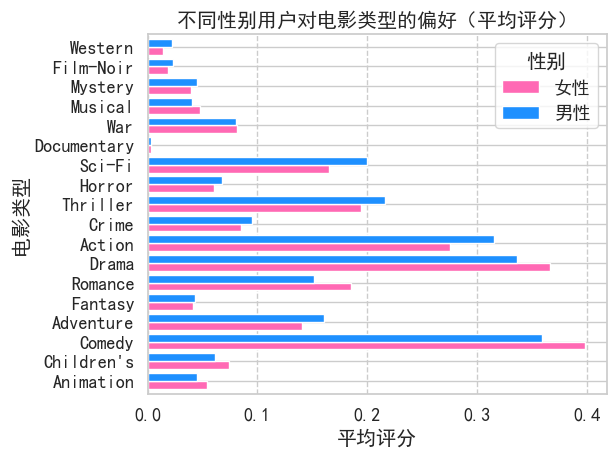

In [35]:
#按预测性别分组计算类型平均分
gender_preference = data.groupby("gender_pred")[genres_list].mean().T

#绘制横向条形图
plt.figure(figsize=(12, 8))
gender_preference.plot.barh(width=0.8, color=["#FF69B4", "#1E90FF"])
plt.title("不同性别用户对电影类型的偏好（平均评分）")
plt.xlabel("平均评分")
plt.ylabel("电影类型")
plt.legend(title="性别", labels=["女性", "男性"])
plt.grid(axis="x", linestyle="--")
plt.tight_layout()
plt.savefig("gender_genre_preference.png")
plt.show()

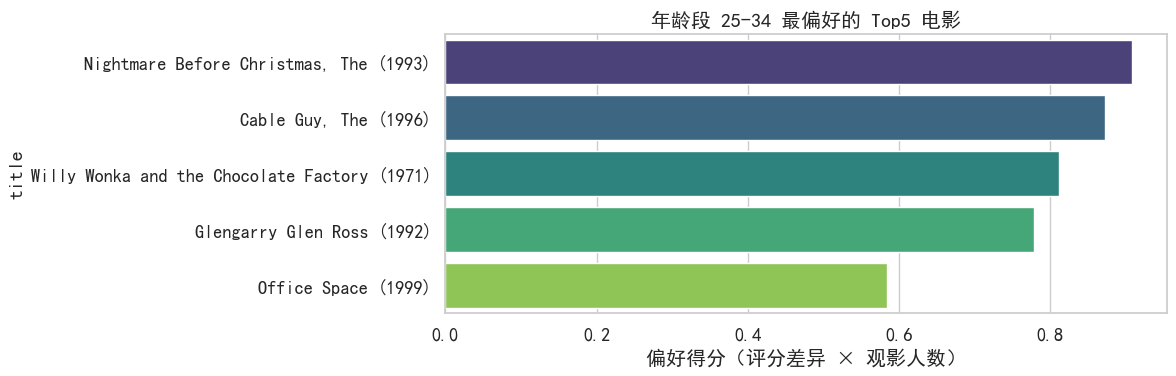

In [36]:
def age_top_movies(age_group):
    #读取包含预测结果的用户数据
    users_with_pred = pd.read_csv("users_with_predictions.csv")
    
    #合并数据
    data = pd.merge(ratings_filtered[["user_id", "movie_id", "rating"]],
        users_with_pred[["user_id", "age_pred"]], on="user_id", how="left")
    data = pd.merge(data, movies[["movie_id", "title", "genres"]], on="movie_id")
    
    #过滤指定年龄段
    age_data = data[data["age_pred"] == age_group]
    
    #计算电影评分指标：评分差异加权
    mean_rating = data.groupby("movie_id")["rating"].mean()
    age_rating = age_data.groupby("movie_id")["rating"].mean()
    count_series = age_data["movie_id"].value_counts()
    
    #确保计算结果是数值型
    diff = (age_rating - mean_rating).fillna(0)  #处理NaN
    log_counts = np.log(count_series + 1)        #确保数值型
    score = diff * log_counts

    #获取Top5电影
    top_movies = score.nlargest(5).index
    top_details = movies[movies["movie_id"].isin(top_movies)][["title", "genres"]]
    
    plt.figure(figsize=(12, 4))
    sns.barplot(x=score[top_movies].values, y=top_details["title"], palette="viridis")
    plt.title(f"年龄段 {age_group} 最偏好的 Top5 电影")
    plt.xlabel("偏好得分（评分差异 × 观影人数）")
    plt.tight_layout()
    plt.savefig(f"age_{age_group}_top_movies.png")
    plt.show()

#示例：可视化25-34岁用户偏好
age_top_movies("25-34")

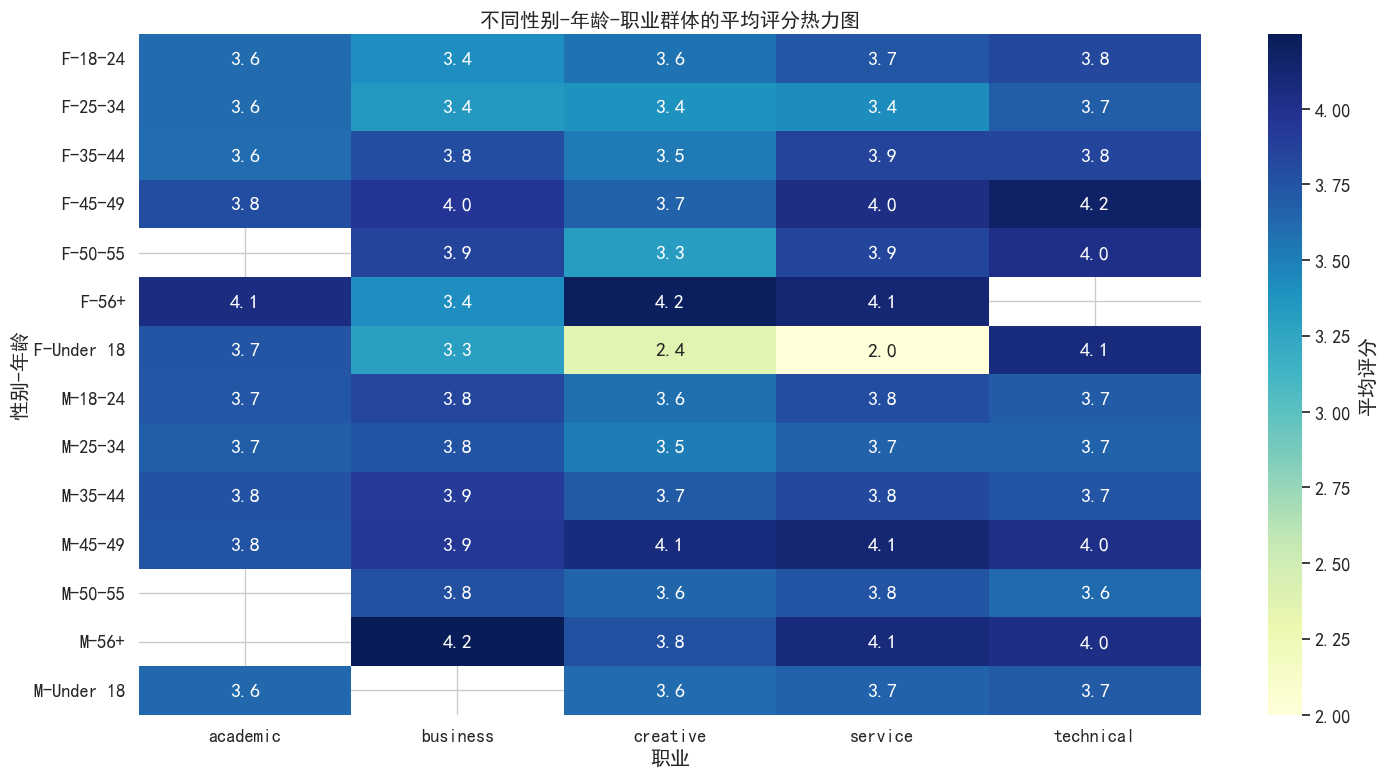

In [37]:
data['rating'] = pd.to_numeric(data['rating'], errors='coerce').fillna(0)

#计算各群体的平均评分
heatmap_data = data.groupby(["gender_pred", "age_pred", "occ_pred"])["rating"].mean().reset_index()
    
#生成透视表
pivot_table = heatmap_data.pivot_table(
    index=["gender_pred", "age_pred"],
    columns="occ_pred",
    values="rating",
    aggfunc="mean"
)
    
#可视化热力图
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={"label": "平均评分"})
plt.title("不同性别-年龄-职业群体的平均评分热力图")
plt.xlabel("职业")
plt.ylabel("性别-年龄")
plt.tight_layout()
plt.savefig("gender_age_occupation_heatmap.png")
plt.show()

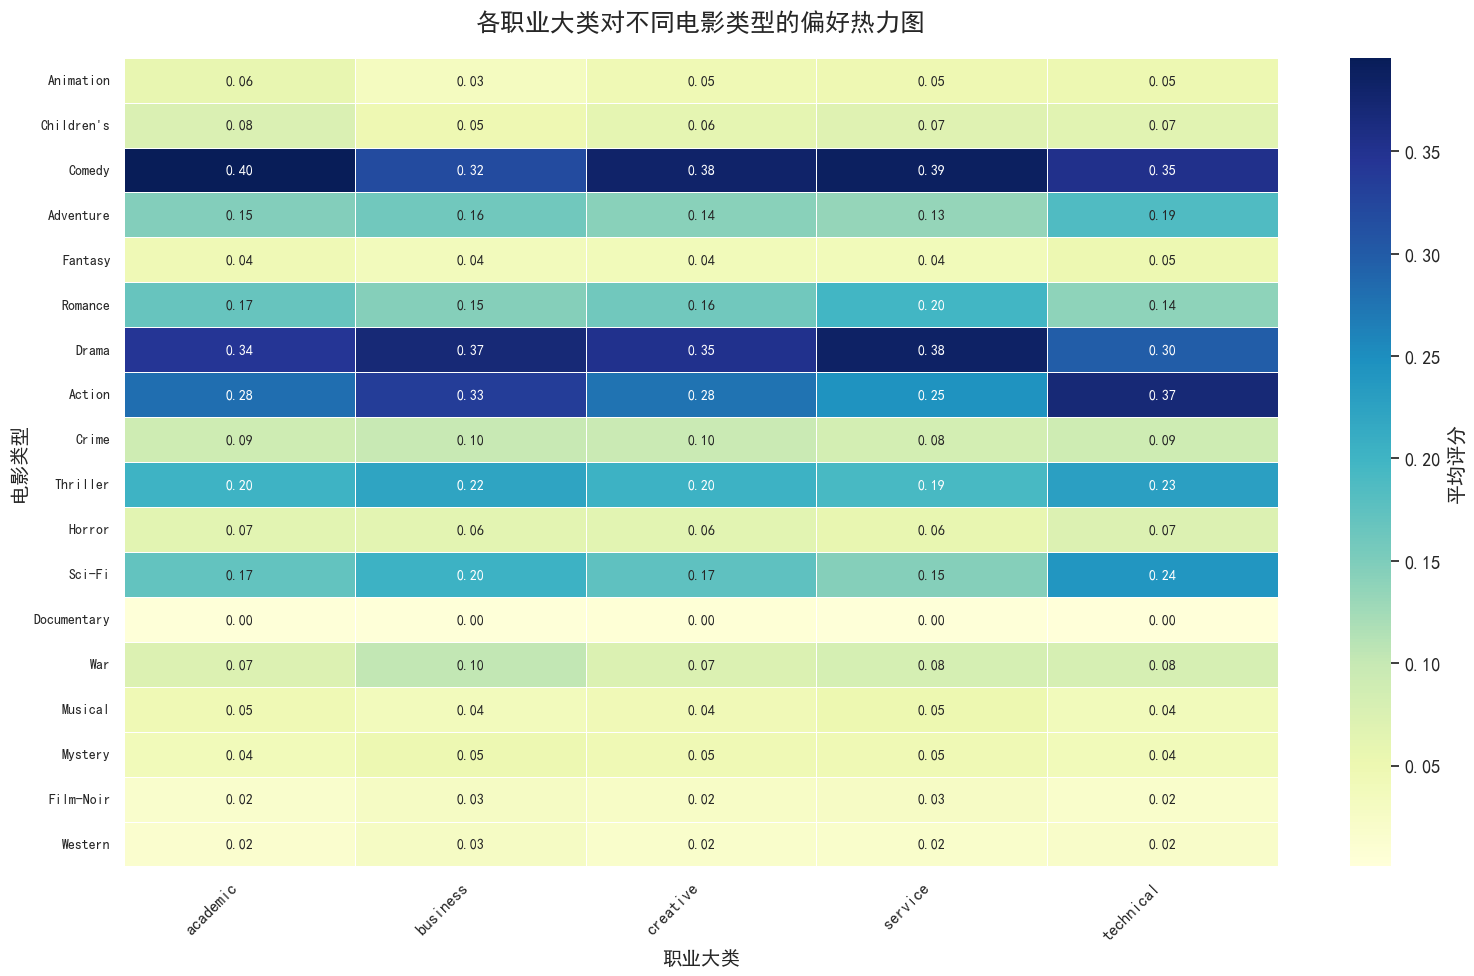


各职业大类最偏好的电影类型:
occ_pred
academic     Comedy
business      Drama
creative     Comedy
service      Comedy
technical    Action
dtype: object


In [38]:
#可视化：不同职业大类对各类电影的喜好程度热力图
def visualize_occupation_preference(data):
    #获取所有电影类型列
    genres_list = [col for col in data.columns if col in user_genre_avg.columns]
    
    #计算每个职业大类对每个类型的平均评分
    preference_df = data.groupby('occ_pred')[genres_list].mean()
    
    #创建热力图
    plt.figure(figsize=(16, 10))
    sns.heatmap(
        preference_df.T,  #转置使类型为行，职业为列
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        linewidths=.5,
        cbar_kws={"label": "平均评分"},
        annot_kws={"size": 10}
    )
    
    plt.title("各职业大类对不同电影类型的偏好热力图", fontsize=18, pad=20)
    plt.xlabel("职业大类", fontsize=14)
    plt.ylabel("电影类型", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig("occupation_genre_preference_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    #各职业最偏好的类型
    top_genres = preference_df.idxmax(axis=1)
    print("\n各职业大类最偏好的电影类型:")
    print(top_genres)
    
    #保存偏好数据到CSV
    preference_df.to_csv("occupation_genre_preference.csv")

#使用完整数据进行可视化
visualize_occupation_preference(data)

### 加入职业及性别、年龄预测优化用户评分

仅加入性别预测和仅加入年龄预测的优化效果不佳，故将期中大作业中的相关代码略去。

这里只保留加入职业、性别、年龄预测优化的结果

In [39]:
ratings = pd.read_csv('./ratings2.csv', header=0, names=['user_id', 'movie_id', 'rating', 'timestamp'],
    dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32'}, encoding='latin-1')
users_pred = pd.read_csv('users_with_predictions.csv', 
    usecols=['user_id', 'gender_pred', 'age_pred', 'occ_pred'],
    dtype={'user_id': 'int32', 'gender_pred': 'category', 'age_pred': 'category', 'occ_pred': 'category'},
    encoding='latin-1'
)
users_raw = pd.read_csv('./users.csv', usecols=['user_id'], dtype={'user_id': 'int32'}, encoding='latin-1')

movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
    dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv('./info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
    dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'}, encoding='latin-1'
    ).rename(columns={'id': 'movie_id'})

def extract_year(time_str):
    try:
        return pd.to_datetime(time_str, errors='coerce').year.fillna(2000).astype(int)
    except:
        return 2000
def process_age(age_desc):
    age_map = {'Under 18': 18, '18-24': 21, '25-34': 30, '35-44': 40, '45-49': 47, '50-55': 52, '56+': 60}
    return age_desc.map(age_map)

#合并用户数据并重命名
users = pd.merge(users_raw, users_pred, on='user_id', how='left').rename(columns={
    'gender_pred': 'gender', 'age_pred': 'age', 'occ_pred': 'occ_desc'})
users['age'] = process_age(users['age'])
movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['starts']

#合并数据集
data = pd.merge(ratings, users[['user_id', 'gender', 'age', 'occ_desc']], on='user_id')
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

data['release_year'] = data['release_year'].fillna(2000)
text_columns = ['creative_team', 'intro', 'directors', 'writers', 'starts']
data[text_columns] = data[text_columns].fillna('Unknown')
data['creative_team'] = data['creative_team'].replace('', 'Unknown')


In [40]:
#用户特征处理（类别型）
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

#电影特征处理
movie_transformer = ColumnTransformer(
    [   ('genres', OneHotEncoder(), ['genres']),

        (   'creative_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(tokenizer=lambda x: x.split('|'),max_features=500,min_df=5)),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ),
            'creative_team'   ),

        (   'intro_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ), 
            'intro'   ),
        
        ('year', 'passthrough', ['release_year'])   ]
)

#全局特征处理器
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender', 'occ_desc']),  #性别和职业做OneHot
    ('age', 'passthrough', ['age']),                     #年龄直接传入
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year'])
], remainder='drop')


In [ ]:
#划分数据集
X = data[['gender', 'age', 'occ_desc', 'genres', 'creative_team', 'intro', 'release_year']]
y = data['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
        subsample=0.8, random_state=42, verbose=-1))
])
#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

from sklearn.metrics import accuracy_score

#将预测值四舍五入到最近整数
y_pred_class = np.round(preds).clip(1, 5)  #限制在1-5分
y_test_class = np.round(y_test).clip(1, 5)

acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')

### 分析细分的电影类型对用户属性的敏感性

分析细分的电影类型对用户属性的敏感性" 需要探索以下两个维度的关系：

用户属性：性别、年龄、职业等

电影类型：喜剧、剧情、动作等细分类型

核心目标是发现不同用户属性群体对特定电影类型的偏好差异

In [ ]:
#方案1：基于机器学习的特征重要性分析
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

#编码职业
le = LabelEncoder()
data['occ_encoded'] = le.fit_transform(data['occ_desc'])

#构建电影类型特征矩阵
genre_features = data['genres'].str.get_dummies(sep='|')

#训练模型预测用户性别
X = genre_features
y = data['gender']
model = RandomForestClassifier()
model.fit(X, y)

#获取特征重要性
importance = pd.DataFrame({'genre': genre_features.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)

print("最能区分性别的电影类型：")
print(importance.head(5))

最能区分性别的电影类型：
      genre  importance
13  Romance    0.214321
0    Action    0.112298
14   Sci-Fi    0.102476
7     Drama    0.093257
4    Comedy    0.080067


In [ ]:
#方案2：基于用户画像的偏好挖掘
#按职业分组统计最受欢迎的电影类型
preference_by_occupation = (data.explode('genres').
    groupby(['occ_desc', 'genres'])['rating'].mean().unstack().T.idxmax()) #.idxmax获取每个职业评分最高的类型

print("各职业最偏好的电影类型：")
print(preference_by_occupation)

各职业最偏好的电影类型：
occ_desc
K-12 student                           Action|Adventure|Comedy|Horror
academic                                        Comedy|Romance|Sci-Fi
academic/educator                      Action|Adventure|Comedy|Horror
artist                                 Adventure|Animation|Children's
business                                                   Sci-Fi|War
clerical/admin                  Action|Adventure|Comedy|Horror|Sci-Fi
college/grad student                                Children's|Horror
creative                                                   Sci-Fi|War
customer service                           Action|Adventure|Animation
doctor/health care           Action|Adventure|Animation|Horror|Sci-Fi
executive/managerial              Adventure|Animation|Sci-Fi|Thriller
farmer                                     Action|Adventure|Animation
homemaker                            Action|Adventure|Horror|Thriller
lawyer                                     Action|Adventure|Animatio

### 期末大作业主要部分

前面对期中大作业作了部分修改，包括修改职业预测部分的建模（将acc从20%提高到32%），修改可视化部分代码及补充相关分析，完善年龄预测部分的序数回归等等。

接下来为期末大作业的主要内容。

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, accuracy_score
from lightgbm import LGBMRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix, hstack
import re

### 期末大作业的第一版优化

In [3]:
#数据加载与预处理
ratings = pd.read_csv('./ratings2.csv', header=0, names=['user_id', 'movie_id', 'rating', 'timestamp'],
                     dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32'}, encoding='latin-1')
users = pd.read_csv('./users.csv', usecols=['user_id', 'gender', 'age_desc', 'occ_desc'],
                   dtype={'user_id': 'int32', 'gender': 'category'}, encoding='latin-1')
movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
                    dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv('./info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
                         dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'}, encoding='latin-1'
                         ).rename(columns={'id': 'movie_id'})

def extract_year(time_str):
    try:
        return pd.to_datetime(time_str, errors='coerce').year.fillna(2000).astype(np.int16)
    except:
        return np.int16(2000)

def process_age(age_desc):
    age_map = {'Under 18': 18, '18-24': 21, '25-34': 30, '35-44': 40, '45-49': 47, '50-55': 52, '56+': 60}
    return age_desc.map(age_map).astype(np.int8)

users['age'] = process_age(users['age_desc'])
users = users.drop(columns=['age_desc'])
users['gender'] = users['gender'].astype('category')

movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['starts']
movies_info = movies_info.drop(columns=['release_time', 'directors', 'writers', 'starts'])

data = pd.merge(ratings, users, on='user_id')
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

In [4]:
#添加新特征

#用户观影频率
user_counts = data['user_id'].value_counts()
data['user_freq'] = data['user_id'].map(user_counts).astype(np.int16)

#电影热度
movie_counts = data['movie_id'].value_counts()
data['movie_popularity'] = data['movie_id'].map(movie_counts).astype(np.int16)

#电影平均评分
movie_avg_rating = data.groupby('movie_id')['rating'].mean().astype(np.float32)
data['movie_avg_rating'] = data['movie_id'].map(movie_avg_rating)

#时间特征
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
data['hour_of_day'] = data['timestamp'].dt.hour.astype(np.int8)
data['day_of_week'] = data['timestamp'].dt.dayofweek.astype(np.int8)
data = data.drop(columns=['timestamp'])

#文本预处理函数
def preprocess_text(text):
    if pd.isna(text):
        return ""
    #移除特殊字符但保留管道符（用于creative_team）
    text = re.sub(r'[^\w\s|]', '', text)
    #转换为小写
    return text.lower().strip()

data['intro'] = data['intro'].apply(preprocess_text)
data['creative_team'] = data['creative_team'].apply(preprocess_text)
data['release_year'] = data['release_year'].fillna(2000).astype(np.int16)

features = ['gender', 'age', 'occ_desc', 'genres', 'creative_team', 
            'intro', 'release_year', 'user_freq', 'movie_popularity', 
            'movie_avg_rating', 'hour_of_day', 'day_of_week']

X = data[features]
y = data['rating'].astype(np.float32)

#划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
#分批处理文本特征
class EfficientTextTransformer:
    def __init__(self, column, is_creative=False, n_components=30):
        self.column = column
        self.is_creative = is_creative
        self.n_components = n_components
        self.vectorizer = None
        self.reducer = None
        
    def fit(self, X, y=None):
        texts = X[self.column].values
        
        #为创意团队使用独特的分词器
        if self.is_creative:
            tokenizer = lambda x: x.split('|')
            max_features = 300  #减少特征数量
        else:
            tokenizer = None
            max_features = 500  #减少特征数量
            
        self.vectorizer = TfidfVectorizer(
            tokenizer=tokenizer,
            max_features=max_features,
            min_df=5,
            ngram_range=(1, 1),
            stop_words='english'
        )
        
        #训练向量化器
        text_features = self.vectorizer.fit_transform(texts)
        
        #使用固定维度的降维
        self.reducer = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.reducer.fit(text_features)
        
        return self
    
    def transform(self, X):
        texts = X[self.column].values
        text_features = self.vectorizer.transform(texts)
        return self.reducer.transform(text_features)
    
    def get_params(self, deep=True):
        return {
            'column': self.column,
            'is_creative': self.is_creative,
            'n_components': self.n_components
        }
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [6]:
#用户特征处理逻辑
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, svd_solver='full', random_state=42))
])

#电影特征处理逻辑
movie_transformer = ColumnTransformer(
    transformers=[
        ('genres', OneHotEncoder(handle_unknown='ignore', sparse_output=True), ['genres']),
        ('creative', EfficientTextTransformer('creative_team', is_creative=True, n_components=20), ['creative_team']),
        ('intro', EfficientTextTransformer('intro', n_components=30), ['intro']),
        ('year', StandardScaler(), ['release_year']),
        ('popularity', StandardScaler(), ['movie_popularity']),
        ('avg_rating', 'passthrough', ['movie_avg_rating'])
    ]
)

#全局特征处理器
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender', 'age', 'occ_desc']),
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year', 'movie_popularity', 'movie_avg_rating']),
    ('time', OneHotEncoder(sparse_output=True), ['hour_of_day', 'day_of_week']),
    ('freq', StandardScaler(), ['user_freq'])
], sparse_threshold=0.8)  #允许混合稀疏/稠密矩阵

#使用LightGBM模型
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=30,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        importance_type='gain',
        verbose=-1,
        max_bin=128,
        min_data_in_leaf=50,
        bin_construct_sample_cnt=500000
    ))
])

In [7]:
#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

#分类准确率评估
y_pred_class = np.round(preds).clip(1, 5)
y_test_class = np.round(y_test.values).clip(1, 5)
acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')

c:\Users\DELL\anaconda3\envs\pythonhomework\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\DELL\anaconda3\envs\pythonhomework\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MSE: 0.8958
Accuracy: 0.3916


### 期末大作业的第二版优化

In [8]:
#1. 用户类型偏好特征
user_genre_stats = ratings.merge(movies, on='movie_id').groupby(['user_id', 'genres'])['rating'].mean().unstack(fill_value=0)
user_genre_stats.columns = [f'ugenre_{col}' for col in user_genre_stats.columns]

#2. 电影创作团队特征
movies_info['main_director'] = movies_info['creative_team'].str.split('|').str[0].str.split(',').str[0]
director_avg = ratings.merge(movies_info, on='movie_id').groupby('main_director')['rating'].mean().to_dict()
movies_info['director_avg'] = movies_info['main_director'].map(director_avg).fillna(3.0)

#3. 用户活跃度特征
user_activity = ratings.groupby('user_id')['rating'].agg(['count', 'mean']).reset_index()
user_activity.columns = ['user_id', 'user_activity', 'user_avg_rating']

#合并关系特征
data = pd.merge(ratings, users, on='user_id')
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')
data = pd.merge(data, user_genre_stats, on='user_id', how='left')
data = pd.merge(data, user_activity, on='user_id', how='left')

#填充缺失值
genre_cols = [col for col in data.columns if col.startswith('ugenre_')]
data[genre_cols] = data[genre_cols].fillna(0)
data['user_activity'] = data['user_activity'].fillna(0)
data['user_avg_rating'] = data['user_avg_rating'].fillna(data['rating'].mean())
data['director_avg'] = data['director_avg'].fillna(3.0)

C:\Users\DELL\AppData\Local\Temp\ipykernel_20656\2579735977.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_genre_stats = ratings.merge(movies, on='movie_id').groupby(['user_id', 'genres'])['rating'].mean().unstack(fill_value=0)


In [9]:
#添加其他特征
user_counts = data['user_id'].value_counts()
movie_counts = data['movie_id'].value_counts()
movie_avg_rating = data.groupby('movie_id')['rating'].mean().astype(np.float32)

new_features = pd.DataFrame({
    'user_freq': data['user_id'].map(user_counts).astype(np.int16),
    'movie_popularity': data['movie_id'].map(movie_counts).astype(np.int16),
    'movie_avg_rating': data['movie_id'].map(movie_avg_rating)
})
data = pd.concat([data, new_features], axis=1)

#时间特征
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
data['hour_of_day'] = data['timestamp'].dt.hour.astype(np.int8)
data['day_of_week'] = data['timestamp'].dt.dayofweek.astype(np.int8)
data = data.drop(columns=['timestamp'])

data['intro'] = data['intro'].apply(preprocess_text)
data['creative_team'] = data['creative_team'].apply(preprocess_text)
data['release_year'] = data['release_year'].fillna(2000).astype(np.int16)

#特征选择
features = [
    'gender', 'age', 'occ_desc', 'genres', 'creative_team', 'intro', 
    'release_year', 'user_freq', 'movie_popularity', 'movie_avg_rating',
    'hour_of_day', 'day_of_week', 'director_avg', 'user_activity', 'user_avg_rating'
] + genre_cols

X = data[features]
y = data['rating'].astype(np.float32)

#划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#关系特征处理器
class RelationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.genre_cols = None
        
    def fit(self, X, y=None):
        self.genre_cols = [col for col in X.columns if col.startswith('ugenre_')]
        return self
    
    def transform(self, X):
        #提取关系特征
        relation_features = X[['director_avg', 'user_activity', 'user_avg_rating'] + self.genre_cols]
        
        #添加交互特征
        interaction_features = pd.DataFrame({
            'genre_match': X.apply(self.calc_genre_match, axis=1), #用户偏好与电影类型匹配度
            'director_interaction': X['director_avg'] * X['user_avg_rating'] #导演评分与用户评分交互
        })
        
        return pd.concat([relation_features, interaction_features], axis=1)
    
    def calc_genre_match(self, row):
        #计算用户偏好与电影类型的匹配度
        movie_genres = set(row['genres'].split('|'))
        match_score = 0
        for genre in movie_genres:
            col_name = f'ugenre_{genre}'
            if col_name in self.genre_cols:
                match_score += row[col_name]
        return match_score / len(movie_genres) if movie_genres else 0

In [11]:
#文本特征处理器
class EfficientTextTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column, is_creative=False, n_components=30):
        self.column = column
        self.is_creative = is_creative
        self.n_components = n_components
        self.vectorizer = None
        self.reducer = None
        
    def fit(self, X, y=None):
        texts = X[self.column].values
        
        if self.is_creative:
            tokenizer = lambda x: x.split('|')
            max_features = 300
        else:
            tokenizer = None
            max_features = 500
            
        self.vectorizer = TfidfVectorizer(
            tokenizer=tokenizer,
            max_features=max_features,
            min_df=5,
            ngram_range=(1, 1),
            stop_words='english'
        )
        
        text_features = self.vectorizer.fit_transform(texts)
        self.reducer = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.reducer.fit(text_features)
        
        return self
    
    def transform(self, X):
        texts = X[self.column].values
        text_features = self.vectorizer.transform(texts)
        return self.reducer.transform(text_features)

In [12]:
#特征处理流水线
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, svd_solver='full', random_state=42))
])

movie_transformer = ColumnTransformer(
    transformers=[
        ('genres', OneHotEncoder(handle_unknown='ignore', sparse_output=True), ['genres']),
        ('creative', EfficientTextTransformer('creative_team', is_creative=True, n_components=20), ['creative_team']),
        ('intro', EfficientTextTransformer('intro', n_components=30), ['intro']),
        ('year', StandardScaler(), ['release_year']),
        ('popularity', StandardScaler(), ['movie_popularity']),
        ('avg_rating', 'passthrough', ['movie_avg_rating'])
    ]
)

#全局特征处理器(添加关系特征)
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender', 'age', 'occ_desc']),
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year', 'movie_popularity', 'movie_avg_rating']),
    ('time', OneHotEncoder(sparse_output=True), ['hour_of_day', 'day_of_week']),
    ('freq', StandardScaler(), ['user_freq']),
    ('relation', RelationTransformer(), features)  #关系特征
], sparse_threshold=0.8)

#模型
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        n_estimators=700,
        learning_rate=0.02,
        max_depth=6,
        num_leaves=35,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_alpha=0.2,
        reg_lambda=0.2,
        random_state=42,
        verbose=-1,
        max_bin=128,
        min_data_in_leaf=50,
        bin_construct_sample_cnt=500000
    ))
])

In [13]:
#训练模型
model.fit(X_train, y_train)

#评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f"改进方案 MSE: {mse:.4f}")

y_pred_class = np.round(preds).clip(1, 5)
y_test_class = np.round(y_test.values).clip(1, 5)
acc = accuracy_score(y_test_class, y_pred_class)
print(f"改进方案 Accuracy: {acc:.4f}")

#特征重要性分析
if hasattr(model.named_steps['regressor'], 'feature_importances_'):
    feature_importances = model.named_steps['regressor'].feature_importances_
    top_features = sorted(enumerate(feature_importances), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 特征重要性:")
    for idx, importance in top_features:
        print(f"特征 {idx}: {importance:.4f}")

c:\Users\DELL\anaconda3\envs\pythonhomework\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\DELL\anaconda3\envs\pythonhomework\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


改进方案 MSE: 0.7426
改进方案 Accuracy: 0.4495
Top 10 特征重要性:
特征 365: 1669.0000
特征 702: 1462.0000
特征 400: 1271.0000
特征 703: 786.0000
特征 364: 736.0000
特征 398: 556.0000
特征 640: 304.0000
特征 577: 247.0000
特征 493: 237.0000
特征 286: 232.0000


In [14]:
import sys
import pandas as pd
from IPython.display import display

key_libraries = [
    'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn',
    'lightgbm', 'xgboost', 'torch', 'tensorflow', 'keras',
    'transformers', 'spacy', 'nltk', 'gensim'
]

lib_versions = []
for lib in key_libraries:
    try:
        version = __import__(lib).__version__
        lib_versions.append((lib, version))
    except ImportError:
        lib_versions.append((lib, "未安装"))

df = pd.DataFrame(lib_versions, columns=['库名称', '版本'])
display(df)

,库名称,版本
0,pandas,2.2.3
1,numpy,2.0.2
2,scikit-learn,未安装
3,matplotlib,3.9.4
4,seaborn,0.13.2
5,lightgbm,4.6.0
6,xgboost,2.1.4
7,torch,2.3.1
8,tensorflow,未安装
9,keras,未安装
